# Notebook 24 — Real-Time Calibration Latency Profiling

This notebook analyzes the execution speed and computational latency of the Rough Heston model calibration pipeline. It compares the performance on:
1. **CPU** (AMD Ryzen 5 5600H)
2. **GPU** (NVIDIA GeForce RTX 3060 Laptop)

We profile:
- `calibrate_newton`: 3D parameter space $(v_0, \zeta, \lambda)$
- `calibrate_newton_h`: 4D parameter space $(v_0, \zeta, \lambda, H)$
- `calibrate_batch`: batched calibration across sizes $B \in \{1, 4, 16, 32, 64\}$



In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

results_path = "../results/latency_breakdown/results.json"
with open(results_path, "r") as f:
    payload = json.load(f)

metadata = payload["metadata"]
results = payload["results"]

print("System CPU:", metadata["cpu"])
print("System GPU:", metadata["gpu"])
print("CUDA Available:", metadata["cuda_available"])



System CPU: AMD Ryzen 5 5600H with Radeon Graphics
System GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA Available: True


## 1. Single-Surface Calibration Latency

We compare the average calibration runtime (in ms) for Newton 3D and Newton 4D (H-parameter space) on CPU vs. GPU.



In [2]:
methods = ["calibrate_newton", "calibrate_newton_h"]
devices = ["cpu", "cuda"]

df_list = []
for m in methods:
    for d in devices:
        if d in results[m]:
            r_data = results[m][d]["full_calibration"]
            df_list.append({
                "Method": m,
                "Device": d.upper(),
                "Mean Latency (ms)": r_data["mean_ms"],
                "Min Latency (ms)": r_data["min_ms"],
                "Max Latency (ms)": r_data["max_ms"],
                "Median Latency (ms)": r_data["median_ms"]
            })
single_df = pd.DataFrame(df_list)
display(single_df)



,Method,Device,Mean Latency (ms),Min Latency (ms),Max Latency (ms),Median Latency (ms)
0,calibrate_newton,CPU,1217.304487,1207.073037,1231.972015,1214.070036
1,calibrate_newton,CUDA,721.930538,721.417539,722.391756,721.846435
2,calibrate_newton_h,CPU,52.822490,52.155883,53.919167,52.493915
3,calibrate_newton_h,CUDA,31.606214,29.668226,36.208947,30.580774


## 2. Step Breakdown Comparison

We inspect the time spent in each step of the Newton calibration iteration (in ms):
- **FNO Forward Pass**: Neural network pricing approximation
- **Jacobian**: Autograd backpropagation to compute derivatives
- **LM Solver**: Linear solver step to solve the Levenberg-Marquardt equations
- **Parameter Update**: Backtracking line search and parameter clamping



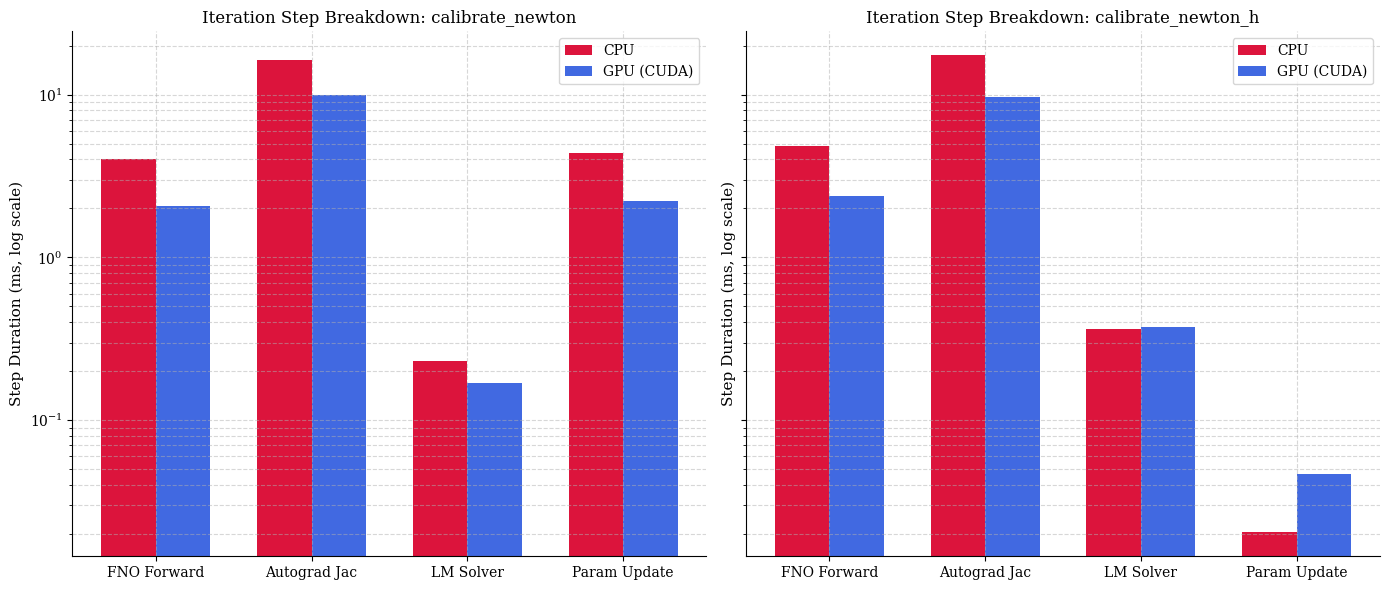

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

steps = ["fno_forward", "jacobian", "lm_solver", "parameter_update"]
step_labels = ["FNO Forward", "Autograd Jac", "LM Solver", "Param Update"]

for idx, m in enumerate(methods):
    ax = axes[idx]
    
    cpu_breakdown = [results[m]["cpu"]["breakdown_ms"][s] for s in steps]
    
    if "cuda" in results[m]:
        gpu_breakdown = [results[m]["cuda"]["breakdown_ms"][s] for s in steps]
        x = np.arange(len(steps))
        width = 0.35
        ax.bar(x - width/2, cpu_breakdown, width, label="CPU", color="crimson")
        ax.bar(x + width/2, gpu_breakdown, width, label="GPU (CUDA)", color="royalblue")
        ax.set_xticks(x)
        ax.set_xticklabels(step_labels)
    else:
        ax.bar(steps, cpu_breakdown, color="crimson", label="CPU")
        
    ax.set_yscale("log")
    ax.set_ylabel("Step Duration (ms, log scale)")
    ax.set_title(f"Iteration Step Breakdown: {m}")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

plt.tight_layout()
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/latency_step_breakdown.png", bbox_inches="tight", dpi=150)
plt.show()



## 3. GPU Speedup Ratios

We calculate the acceleration factors achieved by migrating to the GPU.



In [4]:
print("Acceleration Speedups (CPU Mean / GPU Mean):")
for m in methods:
    if "cuda" in results[m]:
        cpu_mean = results[m]["cpu"]["full_calibration"]["mean_ms"]
        gpu_mean = results[m]["cuda"]["full_calibration"]["mean_ms"]
        speedup = cpu_mean / gpu_mean
        print(f"  {m:22s} : {speedup:.2f}x speedup")
        
        # Breakdown speedups
        print("    Breakdown speedups:")
        for s in steps:
            c_val = results[m]["cpu"]["breakdown_ms"][s]
            g_val = results[m]["cuda"]["breakdown_ms"][s]
            sp = c_val / g_val if g_val > 0 else 0.0
            print(f"      {s:20s}: {sp:.2f}x")



Acceleration Speedups (CPU Mean / GPU Mean):
  calibrate_newton       : 1.69x speedup
    Breakdown speedups:
      fno_forward         : 1.92x
      jacobian            : 1.65x
      lm_solver           : 1.36x
      parameter_update    : 1.97x
  calibrate_newton_h     : 1.67x speedup
    Breakdown speedups:
      fno_forward         : 2.02x
      jacobian            : 1.81x
      lm_solver           : 0.98x
      parameter_update    : 0.44x


## 4. Batched Calibration Scaling

We analyze the scalability of FNO calibrations by measuring throughput (surfaces calibrated per second) across different batch sizes: $B \in \{1, 4, 16, 32, 64\}$.



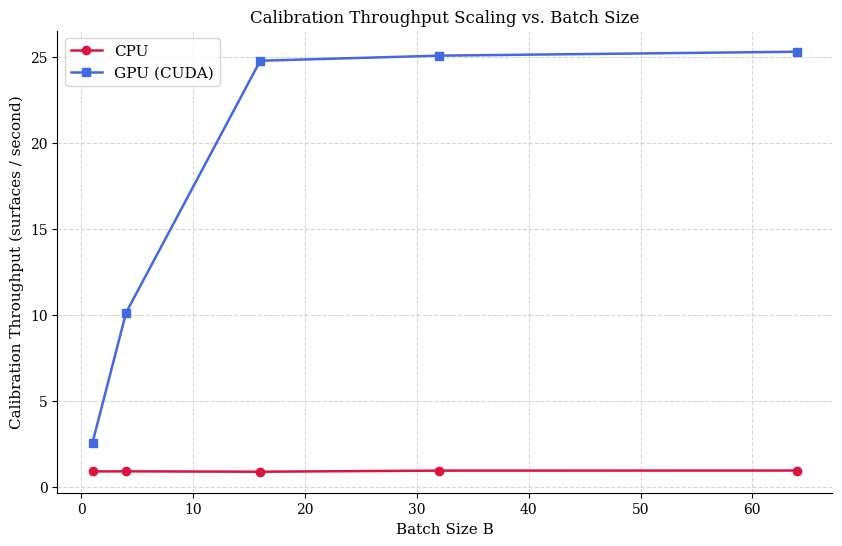

,Batch Size B,CPU Latency (ms),CPU Throughput (surf/s),GPU Latency (ms),GPU Throughput (surf/s),Batch Speedup
0,1,1095.923735,0.912472,386.158465,2.589610,2.838016
1,4,4353.185230,0.918867,394.557475,10.137940,11.033083
2,16,17836.782929,0.897023,645.660466,24.780827,27.625639
3,32,33309.722723,0.960680,1276.101524,25.076375,26.102722
4,64,66254.788293,0.965968,2529.186790,25.304576,26.196083


In [5]:
batch_sizes = [1, 4, 16, 32, 64]
cpu_throughput = []
gpu_throughput = []

for b in batch_sizes:
    key = f"calibrate_batch_{b}"
    if key in results:
        cpu_t = results[key]["cpu"]["full_calibration"]["mean_ms"]
        cpu_throughput.append(b / (cpu_t / 1000.0))
        
        if "cuda" in results[key]:
            gpu_t = results[key]["cuda"]["full_calibration"]["mean_ms"]
            gpu_throughput.append(b / (gpu_t / 1000.0))

plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, cpu_throughput, label="CPU", color="crimson", marker="o", lw=1.8)
if gpu_throughput:
    plt.plot(batch_sizes, gpu_throughput, label="GPU (CUDA)", color="royalblue", marker="s", lw=1.8)
    
plt.xlabel("Batch Size B")
plt.ylabel("Calibration Throughput (surfaces / second)")
plt.title("Calibration Throughput Scaling vs. Batch Size")
plt.grid(True, ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.savefig("../images/latency_batch_scaling.png", bbox_inches="tight", dpi=150)
plt.show()

# Print detailed throughput table
tb_list = []
for idx, b in enumerate(batch_sizes):
    key = f"calibrate_batch_{b}"
    if key in results:
        row = {"Batch Size B": b}
        row["CPU Latency (ms)"] = results[key]["cpu"]["full_calibration"]["mean_ms"]
        row["CPU Throughput (surf/s)"] = cpu_throughput[idx]
        
        if "cuda" in results[key]:
            row["GPU Latency (ms)"] = results[key]["cuda"]["full_calibration"]["mean_ms"]
            row["GPU Throughput (surf/s)"] = gpu_throughput[idx]
            row["Batch Speedup"] = row["CPU Latency (ms)"] / row["GPU Latency (ms)"]
            
        tb_list.append(row)
display(pd.DataFrame(tb_list))

